# Q11. Why did the original final-block fine-tuning fail?

This investigates the original full-block experiment, separate from the later LoRA work. It reloads the archived protocol and original checkpoint, traces all 32 blocks, audits source tensor conversion, and measures one actual optimizer step on the first frozen training variant with a synthetic target. Earlier 32-step diagnostics remain archived. No validation labels or performance estimates are used.

Requires the existing checksum-pinned Q1/Q11 artifacts, `.venv/q9` BioNeMo environment and an H100 GPU. Implementation: [q11_numerics.py](src/q11_numerics.py). Regenerate and execute with `.venv/bin/python -m notebooks.src.q11_numerics --notebook`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent) if Path.cwd().name == "notebooks" else str(Path.cwd()))
from notebooks.src import q11_numerics

In [2]:
result = q11_numerics.reproduce()

Recomputing original checkpoint trace and optimizer probe on the GPU.


Completed in 129.0 s; peak GPU allocation 17.4 GiB.


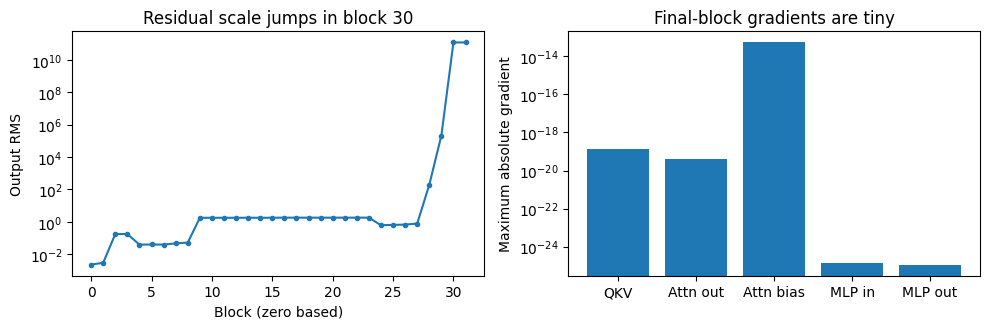

The first training reference enters block 31 with RMS **1.2e+11**. Its attention branch including bias has RMS **0.00597**. The complete block leaves **100%** of elements unchanged.

One synthetic-target step changes **88 FP32 master elements**, but **0 deployed BF16 elements**, with fixed-head score change **0**. Frozen weights, head and restored probe weights all pass equality checks.

In [3]:
q11_numerics.show(result)

In [4]:
q11_numerics.conclusion(result)

**Conclusion.** Original Q11 stopped at its preflight before the supervised epoch. Its final attention block was numerically inactive in this checkpoint/configuration: native QKV normalization weights have RMS about 4.4e-4 and QKV projection weights about 4.4e-6. These very small weights produce a tiny branch beside the enormous block-30 residual. Residual addition loses that contribution, while feature scaling makes the already small gradients smaller. With AdamW's `lr=1e-5` and `eps=1e-8`, the update for a gradient much smaller than epsilon is approximately `lr * gradient / eps`. The fixed diagnostic head also participates in joint clipping (pre-clip norm **32.7**), although its learning rate is zero. These effects explain unchanged deployed weights despite a connected gradient graph and FP32 master weights.

The earlier three-training-variant diagnostic observed zero deployed changes after 32 steps in block 31; block 30 changed 92,362 elements after eight steps. That supports probing block 30 as a different training target, but establishes no pathogenicity performance. Lowering epsilon or increasing precision alone has not been shown to fix final-block training.

Every loaded tensor was compared with the original Savanna checkpoint; tiny final-block weights are already present in that source. The checkpoint alone cannot establish why those weights became tiny during pretraining. Native Savanna/Vortex forward parity is still needed to determine how much of the block-30 activation scale is checkpoint behavior versus backend numerics. The precision replay only recomputes the captured residual addition; it is not a complete FP32/FP64 model run. These training-only synthetic probes do not read validation labels or alter the live Q11 experiment.

The update equation follows the [PyTorch 2.7 AdamW documentation](https://docs.pytorch.org/docs/2.7/generated/torch.optim.AdamW.html). [NVIDIA's model notes](https://docs.nvidia.com/bionemo-framework/2.7.1/main/developer-guide/bionemo-evo2/bionemo-evo2-Overview/index.html) distinguish checkpoint-specific precision behavior; the 1B/40B precision issues should not automatically be assigned to this 7B model.